In [4]:
import pandas as pd

df = pd.read_csv(r'D:\VS code\Data(ML)\Project\Credit Card Fraud Detection\data\creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())
df.head()

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print(df.isnull().sum().sum())
print(df.duplicated().sum())

0
1081


In [6]:
df= df.drop_duplicates()
print(df.shape)
print(df['Class'].value_counts())

(283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64


In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

print(X.shape)
print(y.shape)

(283726, 30)
(283726,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Train shape: (226980, 30)
Test shape: (56746, 30)
Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[['Amount', 'Time']]= scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']]= scaler.fit_transform(X_test[['Amount', 'Time']])


In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[56641    10]
 [   39    56]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


In [13]:
model_smote =LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

predictions_smote = model_smote.predict(X_test)

print(confusion_matrix(y_test, predictions_smote))
print(classification_report(y_test, predictions_smote))

[[55207  1444]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [14]:
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_smote, y_train_smote)

predictions_rf = model_rf.predict(X_test)

print(confusion_matrix(y_test, predictions_rf))
print(classification_report(y_test, predictions_rf))

[[56643     8]
 [   24    71]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [15]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train_smote, y_train_smote)

predictions_xgb = model_xgb.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, predictions_xgb))
print(classification_report(y_test, predictions_xgb))

[[56594    57]
 [   19    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.57      0.80      0.67        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746



In [16]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Har model ke liye probability chahiye, sirf 0/1 prediction nahi
proba_lr = model.predict_proba(X_test)[:, 1]          # Logistic Regression (bina SMOTE)
proba_rf = model_rf.predict_proba(X_test)[:, 1]        # Random Forest
proba_xgb = model_xgb.predict_proba(X_test)[:, 1]      # XGBoost

for name, proba in [('Logistic Regression', proba_lr), ('Random Forest', proba_rf), ('XGBoost', proba_xgb)]:
    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    print(f"{name}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

Logistic Regression: ROC-AUC=0.9562, PR-AUC=0.6936
Random Forest: ROC-AUC=0.9665, PR-AUC=0.8013
XGBoost: ROC-AUC=0.9712, PR-AUC=0.8083


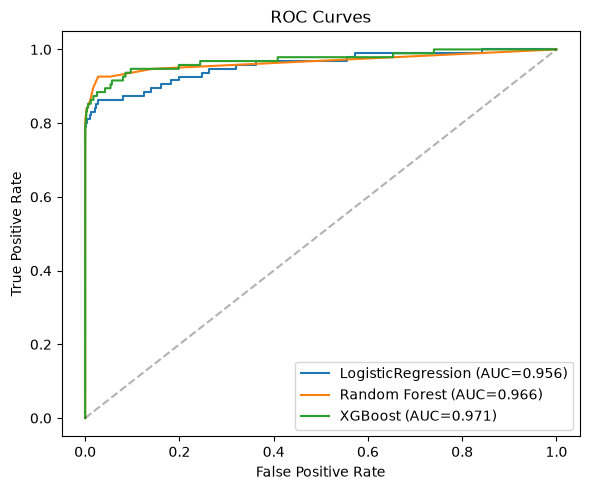

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

plt.figure(figsize=(6,5))
for name, proba in [('LogisticRegression', proba_lr), ('Random Forest', proba_rf), ('XGBoost', proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curves.png', dpi=120)
plt.show()

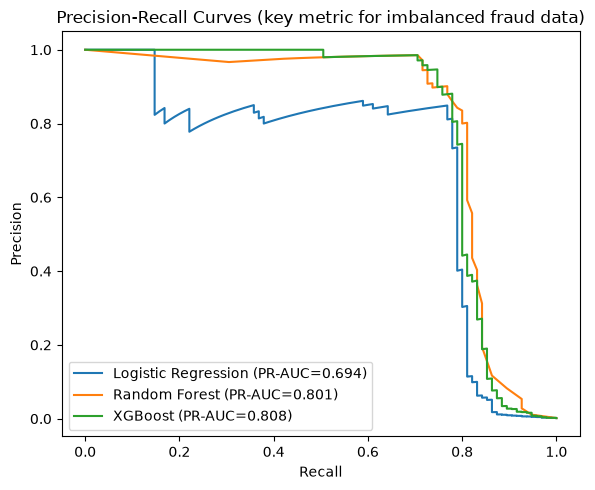

In [18]:
plt.figure(figsize=(6, 5))
for name, proba in [('Logistic Regression', proba_lr), ('Random Forest', proba_rf), ('XGBoost', proba_xgb)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f"{name} (PR-AUC={pr_auc:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (key metric for imbalanced fraud data)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/pr_curves.png', dpi=120)
plt.show()

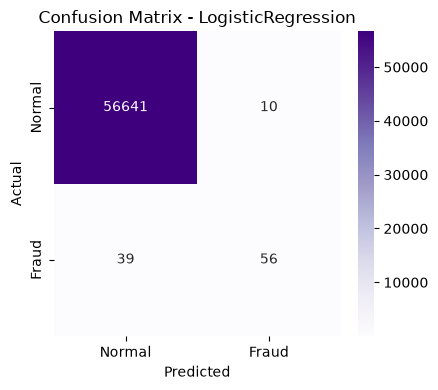

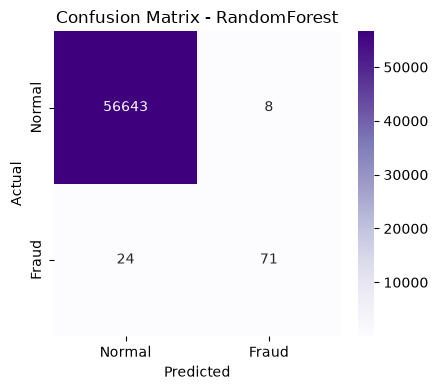

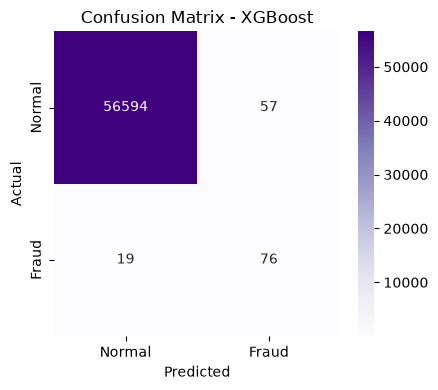

In [19]:
import seaborn as sns

def save_confusion_matrix(name, y_test, predictions):
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'../reports/confusion_matrix_{name}.png', dpi=120)
    plt.show()

save_confusion_matrix('LogisticRegression', y_test, predictions)
save_confusion_matrix('RandomForest', y_test, predictions_rf)
save_confusion_matrix('XGBoost', y_test, predictions_xgb)

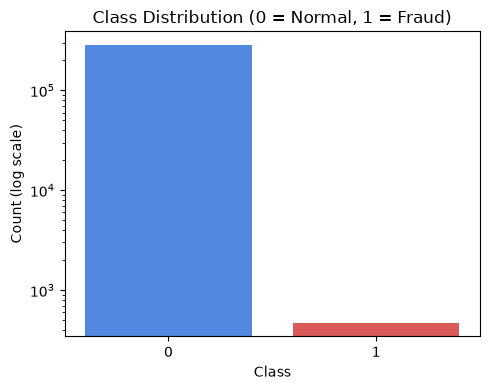

In [20]:
# 1. Class Distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='Class', data=df, hue='Class', palette=['#3B82F6', '#EF4444'], legend=False)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.yscale('log')
plt.ylabel('Count (log scale)')
plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=120)
plt.show()

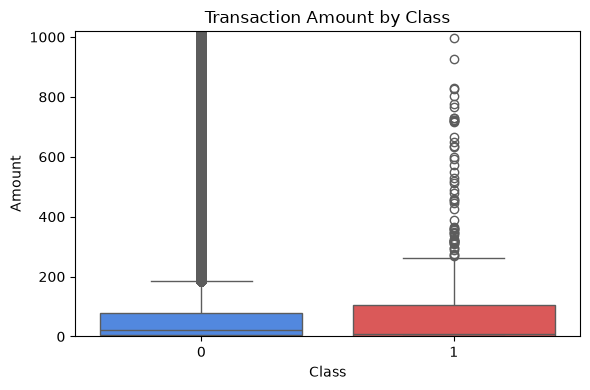

In [21]:
# 2. Amount by Class
plt.figure(figsize=(6, 4))
sns.boxplot(x='Class', y='Amount', data=df, hue='Class', palette=['#3B82F6', '#EF4444'], legend=False)
plt.ylim(0, df['Amount'].quantile(0.99))
plt.title('Transaction Amount by Class')
plt.tight_layout()
plt.savefig('../reports/amount_by_class.png', dpi=120)
plt.show()

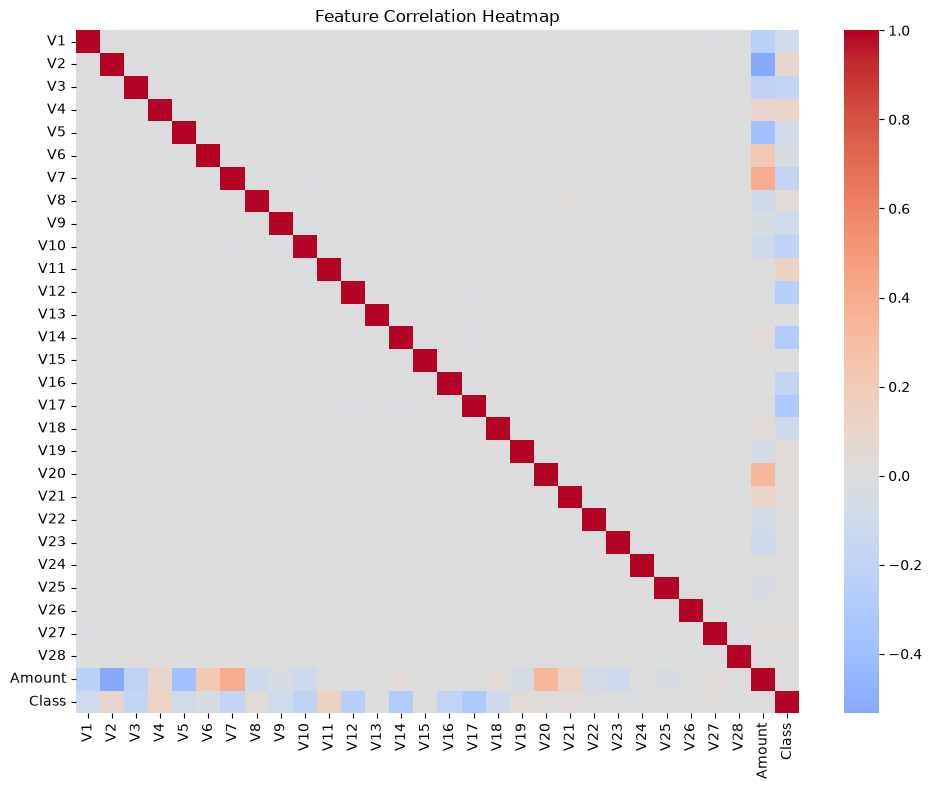

In [22]:
# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df.drop(columns=['Time']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=120)
plt.show()

In [23]:
from sklearn.metrics import average_precision_score

proba_lr= model.predict_proba(X_test)[:, 1]
proba_rf= model_rf.predict_proba(X_test)[:, 1]
proba_xgb=model_xgb.predict_proba(X_test)[:, 1]

pr_auc_lr = average_precision_score(y_test, proba_lr)
pr_auc_rf = average_precision_score(y_test, proba_rf)
pr_auc_xgb = average_precision_score(y_test, proba_xgb)

print("Logistic Regression PR-AUC: ", pr_auc_lr)
print("Random Forest PR-AUC: ", pr_auc_rf)
print("XGBOOST PR-AUC: ", pr_auc_xgb)



Logistic Regression PR-AUC:  0.6935898220997494
Random Forest PR-AUC:  0.8012540365044174
XGBOOST PR-AUC:  0.8082877103629521


In [24]:
import joblib

joblib.dump(model_xgb, '../models/fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(X_train.columns.tolist(), '../models/feature_columns.pkl')

print("Best model (XGBoost) saved successfully!")

Best model (XGBoost) saved successfully!


In [ ]:
import joblib
import pandas as pd

loaded_model = joblib.load('../models/fraud_model.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')
loaded_columns = joblib.load('../models/feature_columns.pkl')

def predict_fraud(transaction_dict):
    row = transaction_dict.copy()
    scaled = loaded_scaler.transform([[row.pop('Amount'), row.pop('Time')]])
    row['Amount'] = scaled[0][0]
    row['Time'] = scaled[0][1]
    X_new = pd.DataFrame([row])[loaded_columns]
    proba = loaded_model.predict_proba(X_new)[0][1]
    is_fraud = proba >= 0.5
    return {"fraud_probability": round(float(proba), 5), "is_fraud": bool(is_fraud)}

In [32]:
# Test 1: Ek real FRAUD transaction try karo
fraud_row = df[df['Class'] == 1].iloc[0].drop('Class').to_dict()
print("Fraud transaction test:", predict_fraud(fraud_row))

# Test 2: Ek real NORMAL transaction try karo
normal_row = df[df['Class'] == 0].iloc[0].drop('Class').to_dict()
print("Normal transaction test:", predict_fraud(normal_row))

Fraud transaction test: {'fraud_probability': 0.99914, 'is_fraud': True}
Normal transaction test: {'fraud_probability': 0.00082, 'is_fraud': False}


c:\Users\anshu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\anshu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


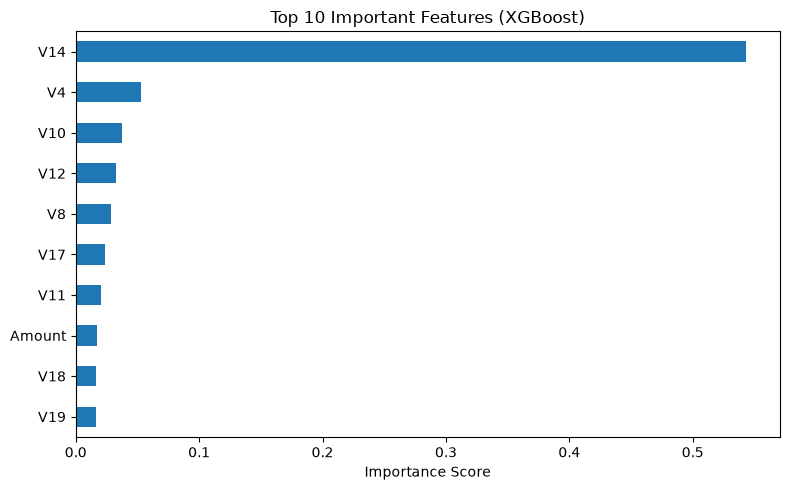

In [33]:
import matplotlib.pyplot as plt

importances = loaded_model.feature_importances_
feat_imp = pd.Series(importances, index=loaded_columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh')
plt.title('Top 10 Important Features (XGBoost)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=120)
plt.show()